# P2: Python Project - Leslie Alhakim

## Part 1: Data Wrangling

In [15]:
### Load libraries and dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px 
import plotly.io as pio
pio.renderers.default = "browser"

df = pd.read_csv('~/Downloads/Data Viz/P2/og.csv')
df.head(10)

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa
5,Antigua and Barbuda,86,3,65,18,4,0,5,3.49,75.58,4.62,76,10,13.16,Americas
6,Argentina,167416,3059,72575,91782,4890,120,2057,1.83,43.35,4.21,130774,36642,28.02,Americas
7,Armenia,37390,711,26665,10014,73,6,187,1.90,71.32,2.67,34981,2409,6.89,Europe
8,Australia,15303,167,9311,5825,368,6,137,1.09,60.84,1.79,12428,2875,23.13,Western Pacific
9,Austria,20558,713,18246,1599,86,1,37,3.47,88.75,3.91,19743,815,4.13,Europe


In [16]:
### Data cleaning & transformation
df.info()
df.isna().sum()
df.describe()

df = df.rename(columns={
    "Country/Region": "country",
    "Confirmed": "confirmed",
    "Deaths": "deaths",
    "Recovered": "recovered",
    "Active": "active",
    "New cases": "new_cases",
    "New deaths": "new_deaths",
    "New recovered": "new_recovered",
    "Deaths / 100 Cases": "deaths_per_100_cases",
    "Recovered / 100 Cases": "recovered_per_100_cases",
    "Deaths / 100 Recovered": "deaths_per_100_recovered",
    "Confirmed last week": "confirmed_last_week",
    "1 week change": "one_week_change",
    "1 week % increase": "one_week_pct_increase",
    "WHO Region": "region"
})

df.columns

df = df.drop(columns=["deaths_per_100_recovered"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning:

invalid value encountered in subtract



In [17]:
### Add new required metrics
df["CFR"] = (df["deaths"] / df["confirmed"]) * 100
df["recovery_rate"] = (df["recovered"] / df["confirmed"]) * 100

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["CFR", "recovery_rate"])

df.head(10)

,country,confirmed,deaths,recovered,active,new_cases,new_deaths,new_recovered,deaths_per_100_cases,recovered_per_100_cases,confirmed_last_week,one_week_change,one_week_pct_increase,region,CFR,recovery_rate
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,35526,737,2.07,Eastern Mediterranean,3.499435,69.486805
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,4171,709,17.00,Europe,2.950820,56.250000
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,23691,4282,18.07,Africa,4.157581,67.339935
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,884,23,2.60,Europe,5.733186,88.533627
4,Angola,950,41,242,667,18,1,0,4.32,25.47,749,201,26.84,Africa,4.315789,25.473684
5,Antigua and Barbuda,86,3,65,18,4,0,5,3.49,75.58,76,10,13.16,Americas,3.488372,75.581395
6,Argentina,167416,3059,72575,91782,4890,120,2057,1.83,43.35,130774,36642,28.02,Americas,1.827185,43.350098
7,Armenia,37390,711,26665,10014,73,6,187,1.90,71.32,34981,2409,6.89,Europe,1.901578,71.315860
8,Australia,15303,167,9311,5825,368,6,137,1.09,60.84,12428,2875,23.13,Western Pacific,1.091289,60.844279
9,Austria,20558,713,18246,1599,86,1,37,3.47,88.75,19743,815,4.13,Europe,3.468236,88.753770


In [18]:
### Group by region
region_summary = (
    df.groupby("region")
      .agg(
          total_confirmed=("confirmed", "sum"),
          total_deaths=("deaths", "sum"),
          total_recovered=("recovered", "sum"),
          total_active=("active", "sum"),
          mean_CFR=("CFR", "mean"),
          mean_recovery_rate=("recovery_rate", "mean")
      )
      .reset_index()
)

region_summary

,region,total_confirmed,total_deaths,total_recovered,total_active,mean_CFR,mean_recovery_rate
0,Africa,723207,12223,440645,270339,2.305681,57.014470
1,Americas,8839286,342732,4468616,4027938,3.052169,62.291809
2,Eastern Mediterranean,1490744,38339,1201400,251005,3.563603,66.592722
3,Europe,3299523,211144,1993723,1094656,4.198406,68.634834
4,South-East Asia,1835297,41349,1156933,637015,1.295804,66.703736
5,Western Pacific,292428,8249,206770,77409,1.290351,76.804198


In [19]:
### Save cleaned CSV
df.to_csv("NEW.csv", index=False)

## Part 1: Summary
I loaded the necessary packages and the COVID-19 file. After looking more closely at the data (info/NAs), ii decided to standardize tthe column names, remove invalid metrics, and compute the Case Fatality Rate (CFR) and Recovery Rate using the provided formulas. I also handled division-by-zero issues and ensured that all metrics were clean and numeric for visualization. Finally, I grouped the data by WHO region to support higher-level trend analysis and comparisons across regions in the later visualization steps.

## Part 2: Data Visualization with Matplotlib and Seaborn

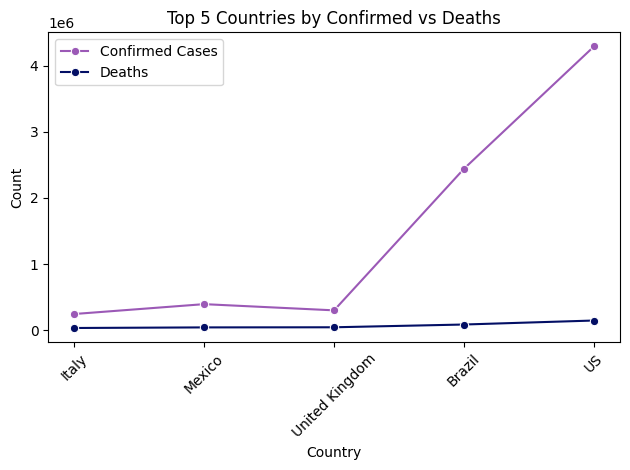

In [20]:
### Line chart: Top 5 countries deaths over confirmed cases 
top5 = df.nlargest(5, "deaths").sort_values("deaths")

sns.lineplot(
    data=top5,
    x="country",
    y="confirmed",
    marker="o",
    label="Confirmed Cases",
    color="#9B59B6"
)

sns.lineplot(
    data=top5,
    x="country",
    y="deaths",
    marker="o",
    label="Deaths",
    color="#030F65"
)

plt.title("Top 5 Countries by Confirmed vs Deaths")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

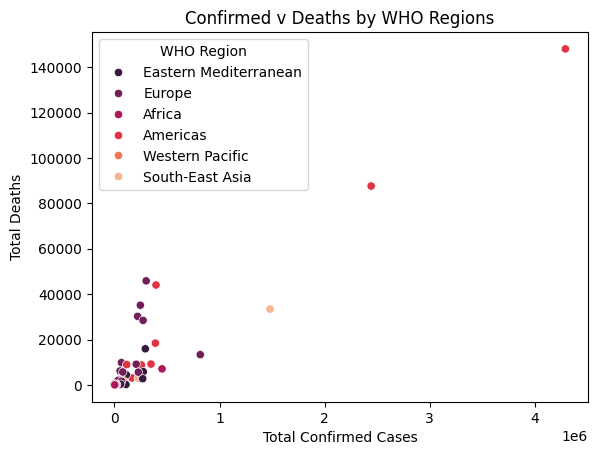

In [21]:
### Scatter plot: Confirmed vs. Deaths with WHO Region colors
sns.scatterplot(
    data=df,
    x="confirmed",y="deaths", 
    hue="region",
    palette="rocket")

plt.title("Confirmed v Deaths by WHO Regions")
plt.xlabel("Total Confirmed Cases")
plt.ylabel("Total Deaths")
plt.legend(title="WHO Region")
plt.show()

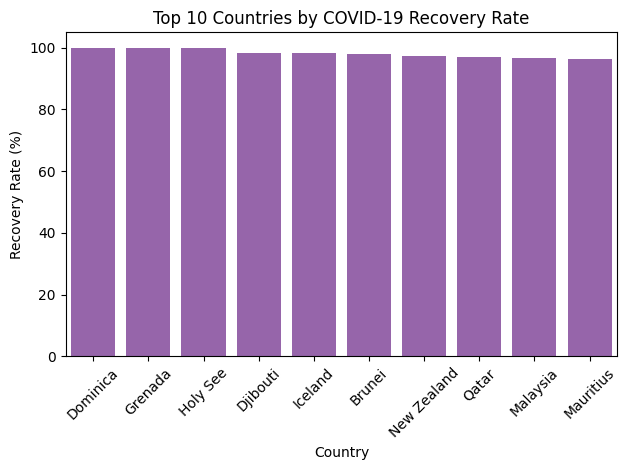

In [22]:
### Bar chart: Top 10 countries by recovery rate
top10 = df.nlargest(10, "recovery_rate")
top10

sns.barplot(
    data=top10,
    x="country",
    y="recovery_rate",
    color= "#9B59B6")

plt.title("Top 10 Countries by COVID-19 Recovery Rate")
plt.xlabel("Country")
plt.ylabel("Recovery Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

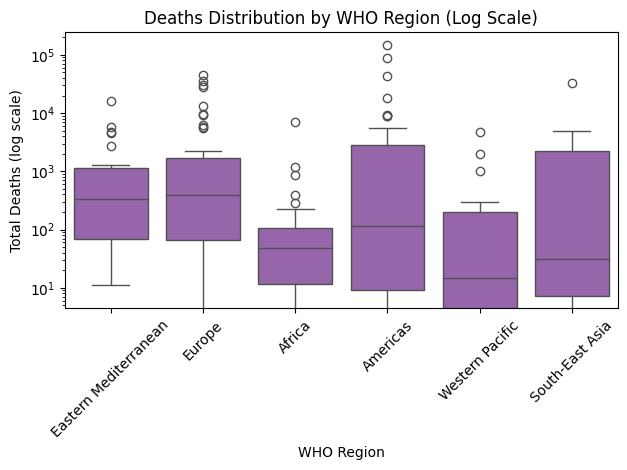

In [23]:
### Box plot: Deaths distribution by WHO Region
sns.boxplot(
    data=df,
    x="region",y="deaths",
    color="#9B59B6")

plt.yscale('log') # added for readibility; was really ugly before
plt.title("Deaths Distribution by WHO Region (Log Scale)")
plt.xlabel("WHO Region")
plt.ylabel("Total Deaths (log scale)")
plt.xticks(rotation=45) #again, added for readibility
plt.tight_layout()
plt.show()

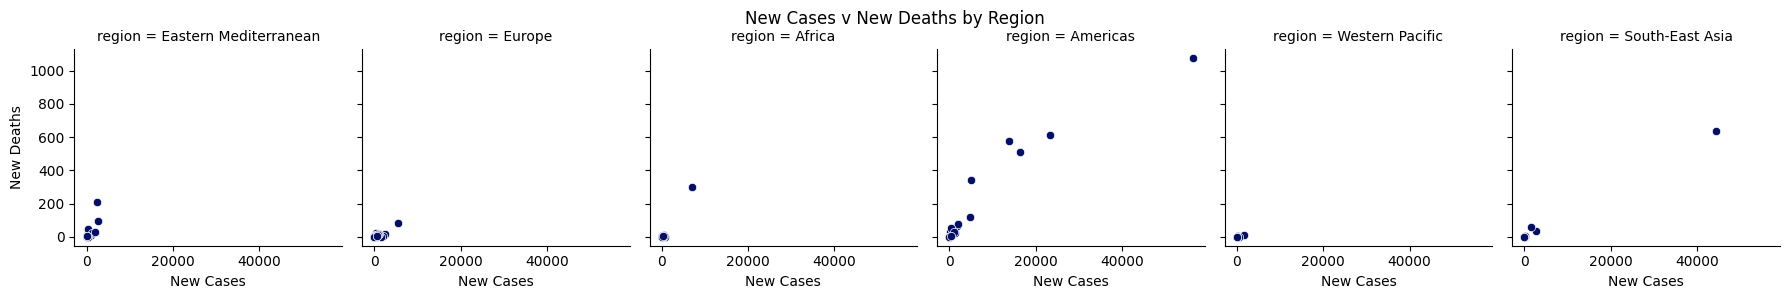

In [24]:
### Faceted plot: New cases vs New deaths by region
g = sns.FacetGrid(df, col="region")
g.map(sns.scatterplot, "new_cases", "new_deaths", color="#030F65")

g.fig.suptitle("New Cases v New Deaths by Region")
g.fig.subplots_adjust(top=0.85) #overlapped before
g.set_axis_labels("New Cases", "New Deaths")
plt.show()

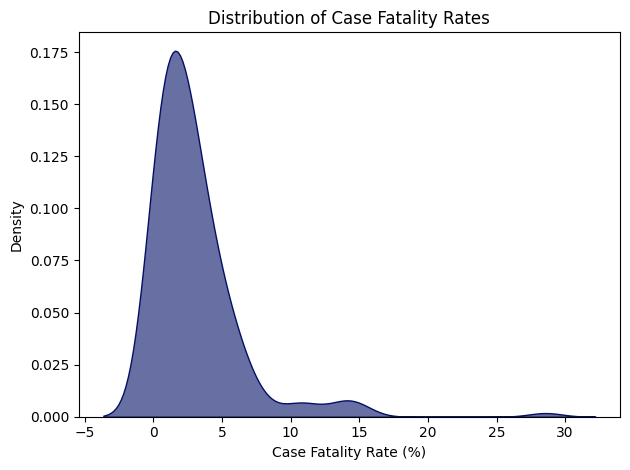

In [25]:
### Density plot: Distribution of case fatality rates
sns.kdeplot(
    data=df,
    x="CFR",
    fill=True,
    alpha=0.6,
    color="#030F65"
)

plt.title("Distribution of Case Fatality Rates")
plt.xlabel("Case Fatality Rate (%)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

## Part 3: Interactive Visualizations with Plotly

In [26]:
### Interactive Scatter plot: Confirmed vs. Deaths with WHO Region colors
fig_scatter = px.scatter(
    df,
    x="confirmed",
    y="deaths",
    color="region",
    hover_name="country",
    hover_data={
        "confirmed": True,
        "deaths": True,
        "CFR": True,
        "recovery_rate": True
    },
    title="Confirmed Cases v Deaths by WHO Region",
    labels={
        "confirmed": "Total Confirmed Cases",
        "deaths": "Total Deaths",
        "region": "WHO Region"
    }
)

fig_scatter.show()

In [27]:
### Line chart: Top 5 countries deaths over confirmed cases
top5 = df.nlargest(5, "deaths").sort_values("deaths")

top5_long = top5.melt(
    id_vars=["country"],
    value_vars=["confirmed", "deaths"],
    var_name="metric",
    value_name="count"
) # have to switch from wide to long for both lines

fig_line = px.line(
    top5_long,
    x="country",
    y="count",
    color="metric",
    markers=True,
    title="Top 5 Countries by Confirmed vs Deaths",
    labels={
        "country": "Country",
        "count": "Count",
        "metric": "Metric"
    }
)

fig_line.show()


## Part 4: Build a Dashboard
See app.py file

## Part 5: Interpret Your Results
Q: Which of the top 5 countries with the highest death counts have the highest death rates relative to their confirmed cases?
A: The visualizations indicate that both Italy and the United States show the highest death burden compared to their number of confirmed cases

Q: How does the relationship between confirmed cases and deaths vary across WHO regions, and how does recovery size factor in?
A: Overall, more confirmed cases indicate more deaths with the Americas and Europe having the highest case and deathh totals and Africa and the Western Pacific having lower. In regions where a lot of people recovered, there is still a lot of deaths if the total case count was large.

Q: Which ten countries have achieved the highest recovery rates?
A: The ten countries with the highest recovery rates were: Dominica, Grenada, Holy See, Djibouti, Iceland, Brunei, New Zealand, Qatar, Malaysia, and Mauritius.

Q: How does the distribution of deaths vary between different WHO regions?
A: The Americas and Europe show the largest range and have the highest death outliers. On the other hand, Africa and the Western Pacific were more consistent with lower death counts overall and had less variation between countries.

Q: Is there a correlation between new cases and new deaths across all regions?
A: Yes, there is a correlation between new cases and new deaths across all regions as countries with more new cases tended to report more new deaths, especially in the Americas and Europe.

Q: What is the typical distribution of death rates per 100 cases across all countries?
A: The visualizations show that most countries cluster between 0-5% with the most being around 2-3%. 